# Capstone Assignment 20.1: Initial Report and Exploratory Data Analysis

**Overview**: This notebook provides exploratory data analysis and a baseline model on the [Real / Fake Job Posting Prediction Dataset](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction), making use of the article accompanying the dataset [here](https://www.icsd.aegean.gr/publication_files/290421648.pdf)



### Problem 1: Understanding the Data

Before modeling, we confirm:
- the prediction target (binary classification),
- feature types (numeric vs categorical),
- missing values
- class imbalance 

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [14]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English

from wordcloud import WordCloud

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

In [5]:
job_postings = pd.read_csv('data/fake_job_postings.csv')
print("Shape:", job_postings.shape)

Shape: (17880, 18)


In [5]:
job_postings.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
job_postings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### Observations

Given the column info and head samples, we can deduce the following:
- job_id is a unique ID which likely has little correlation to fraudulence
- salary range likely correlates to region/country. An unrealistic range -- too wide, or atypical to the job title - could correlate to fraudulency

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


In [ ]:
job_postings.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'na_count': df.isna().sum(),
    'na_percentage': (df.isna().sum() / len(df)) * 100,
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.sample().iloc[0]
  })


In [9]:
data_quality_report(job_postings)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
job_id,int64,17880,0,0,0.000000,0.000000,17880,13055
title,object,17880,0,0,0.000000,0.000000,11231,Customer Service Associate - Part Time
location,object,17534,346,346,1.935123,1.935123,3105,"US, CA, Milpitas"
department,object,6333,11547,11547,64.580537,64.580537,1337,NaN
salary_range,object,2868,15012,15012,83.959732,83.959732,874,NaN
company_profile,object,14572,3308,3308,18.501119,18.501119,1709,"Novitex Enterprise Solutions, formerly Pitney ..."
description,object,17879,1,1,0.005593,0.005593,14801,The Customer Service Associate will be based i...
requirements,object,15184,2696,2696,15.078300,15.078300,11967,Minimum Requirements:Minimum of 6 months custo...
benefits,object,10668,7212,7212,40.335570,40.335570,6204,NaN
telecommuting,int64,17880,0,0,0.000000,0.000000,2,0


### Most Missing Columns

Fraudulent postings often have more missing fields, e.g. no company logo, salary range, company profile.

/var/folders/zq/7j33ffkd46vd0yzyrk5qyj140000gn/T/ipykernel_41840/942558542.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_class = job_postings.groupby('fraudulent').apply(


fraudulent                  0         1
salary_range         0.844540  0.742494
company_profile      0.159927  0.677829
department           0.647467  0.613164
required_education   0.449865  0.520785
required_experience  0.388797  0.502309
benefits             0.402492  0.420323
function             0.359586  0.389145
industry             0.272011  0.317552
employment_type      0.189844  0.278291
requirements         0.149406  0.177829
location             0.019219  0.021940
description          0.000000  0.001155
job_id               0.000000  0.000000
telecommuting        0.000000  0.000000
has_questions        0.000000  0.000000
has_company_logo     0.000000  0.000000
title                0.000000  0.000000
fraudulent           0.000000  0.000000


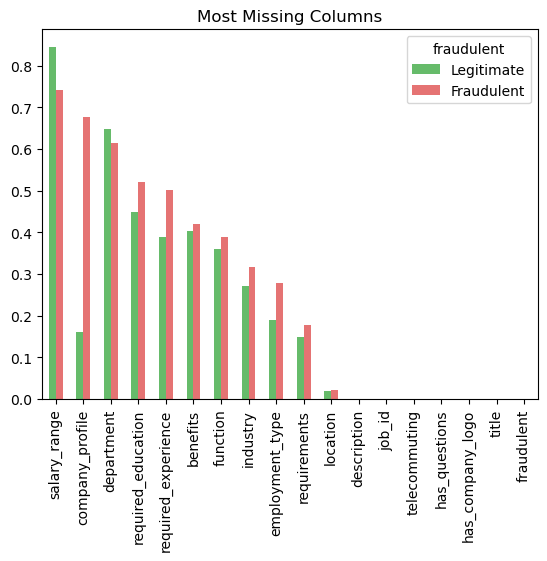

In [32]:
missing_by_class = job_postings.groupby('fraudulent').apply(
    lambda x: x.isnull().mean()
).T.sort_values(by=1, ascending=False)
print(missing_by_class)

##     ct.plot(kind='bar', color=['#E57373', '#66BB6A'], width=0.8, ax=axes[idx])
missing_plot = missing_by_class.plot(kind='bar', color=['#66BB6A', '#E57373'], legend=['Legitimate', 'Fraudulent'], title="Most Missing Columns")
legend = missing_plot.get_legend()

for text, label in zip(legend.get_texts(), ['Legitimate', 'Fraudulent']):
    text.set_text(label)

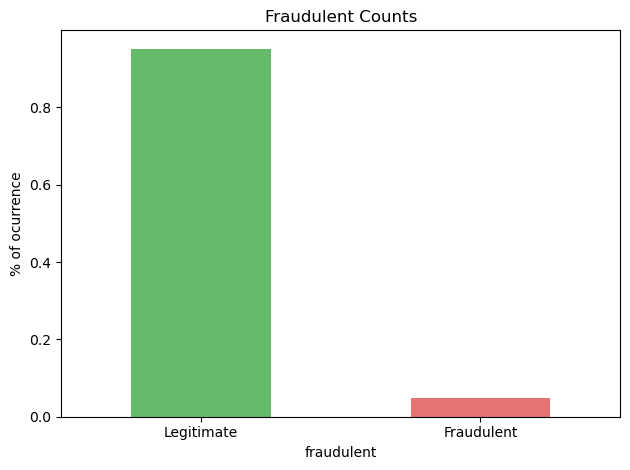

In [70]:
fraudulent_counts = job_postings['fraudulent'].value_counts(normalize=True)

fraudulent_counts.plot(title="Fraudulent Counts", kind="bar", color=['#66BB6A', '#E57373'])
plt.ylabel("% of ocurrence")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()

### Problem 4: Understanding the Task

**Business objective:** predict which job postings are fraudulent vs legitimate, so applicants can avoid providing PPI to scammers.

**ML objective:** learn a mapping from customer features to a binary response label and evaluate competing classifiers using cross-valdiation and a held-out test set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [7]:
num_cols = job_postings.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = job_postings.select_dtypes(include='object').columns.tolist()

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
Categorical features: ['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']


In [8]:
for col in cat_cols:
    job_postings[col] = job_postings[col].fillna("unknown")

<Axes: >

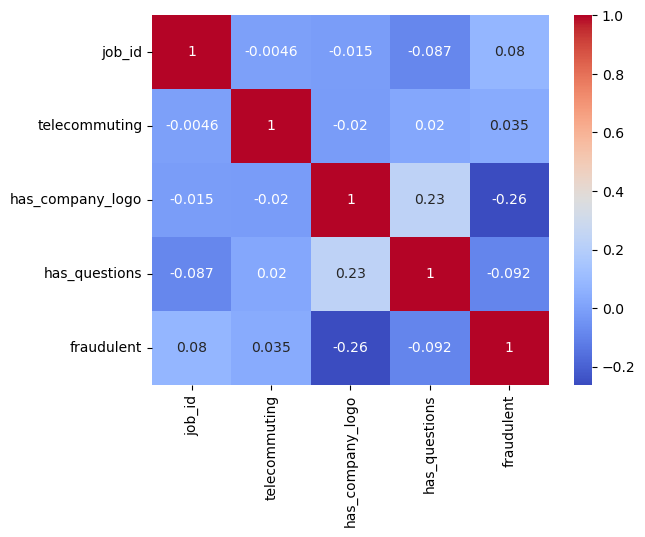

In [66]:
sns.heatmap(job_postings[num_cols].corr(), cmap='coolwarm', annot=True)

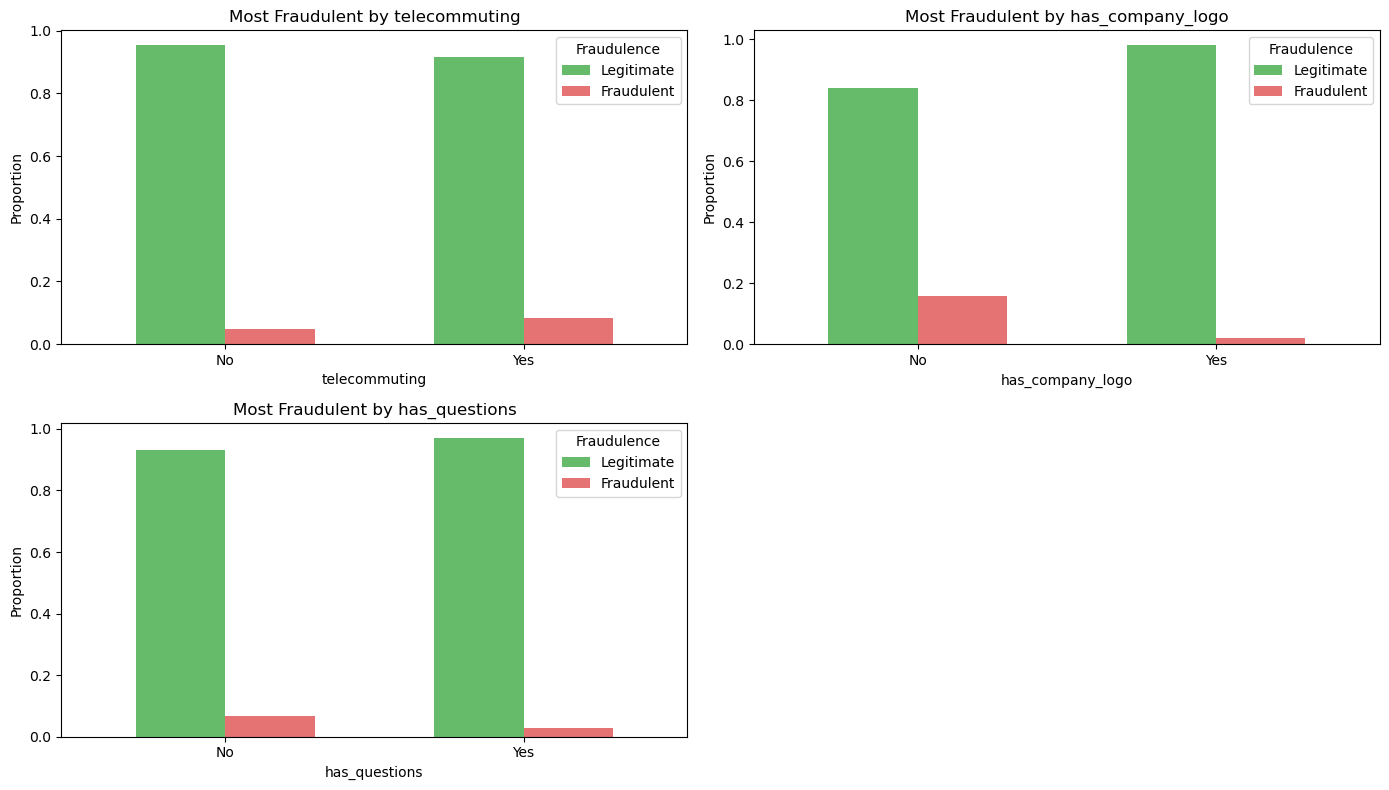

In [64]:
num_to_plot = [c for c in num_cols if c not in ['job_id', 'fraudulent']]

# Calculate rows and columns for better layout
n_plots = len(num_to_plot)
n_cols = 2  # or however many columns you want
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))

# This safely handles 1x1, 1D, and 2D arrays identically
axes = np.array(axes).flatten()

# Plot each distribution
for idx, col in enumerate(num_to_plot):
   
    ct = pd.crosstab(job_postings[col], job_postings['fraudulent'], normalize='index')
    
    # Stacked bar chart
    ct.plot(kind='bar', 
            ax=axes[idx], 
            color=['#66BB6A', '#E57373'],
            width=0.6)
    
    axes[idx].set_title(f"Most Fraudulent by {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Proportion")
    axes[idx].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[idx].legend(['Legitimate', 'Fraudulent'], title='Fraudulence')

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('images/numerical_bar_plots.png')
plt.show()

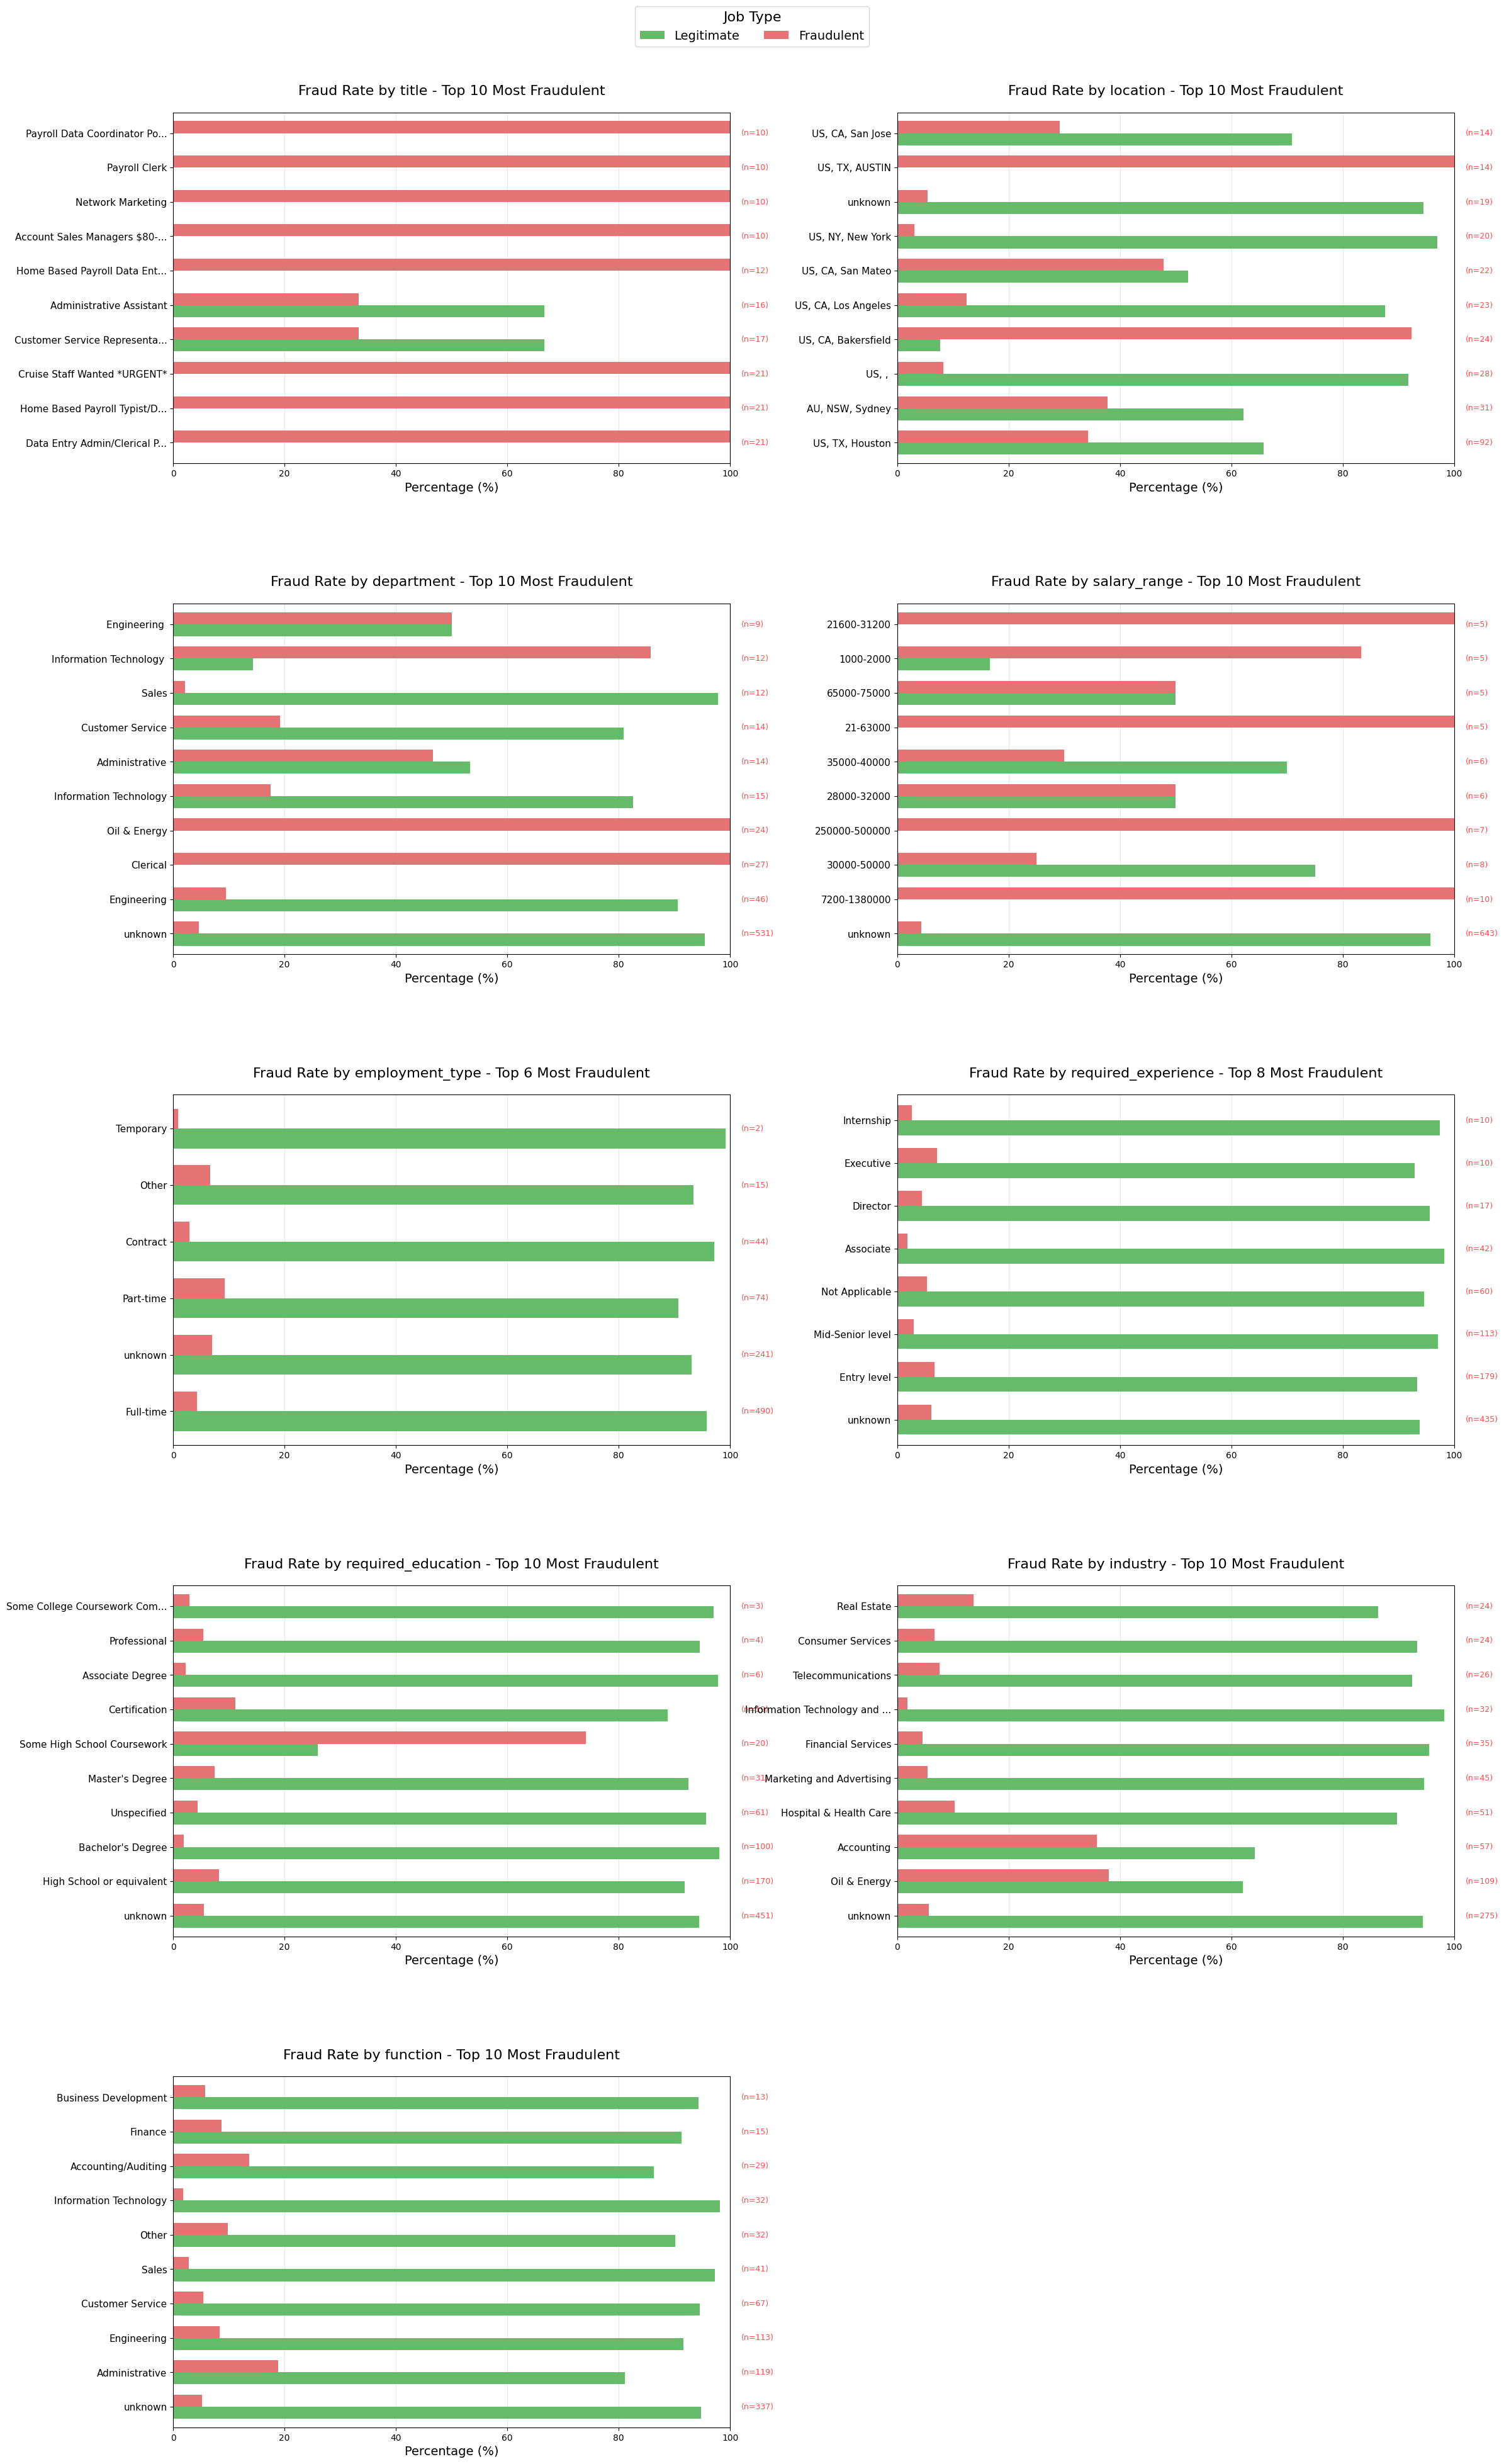

In [ ]:
text_columns = ['description', 'company_profile', 'requirements', 'benefits'] 
cat_to_plot = [c for c in cat_cols if c not in ['fraudulent'] + text_columns]

# Calculate rows and columns for better layout
n_plots = len(cat_to_plot)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure with even larger size for horizontal bars
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8 * n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Plot each categorical variable
for idx, col in enumerate(cat_to_plot):
    # Get categories with highest fraud counts (fraudulent == 1)
    fraud_counts = job_postings[job_postings['fraudulent'] == 1][col].value_counts().head(10)
    top_fraud_categories = fraud_counts.index
    
    # Filter data to only include top fraudulent categories
    filtered_data = job_postings[job_postings[col].isin(top_fraud_categories)]
    
    # Create crosstab with percentages for filtered data
    ct = pd.crosstab(filtered_data[col], filtered_data['fraudulent'], normalize='index') * 100
    
    # Reorder by fraud count (most fraudulent first)
    ct = ct.reindex(top_fraud_categories)
    
    # Create horizontal bar plot
    ct.plot(kind='barh', 
            color=['#66BB6A', '#E57373'],
            width=0.7, 
            ax=axes[idx])
    
    # Set title and labels
    axes[idx].set_title(f"Fraud Rate by {col} - Top {len(top_fraud_categories)} Most Fraudulent", fontsize=16, pad=20)
    axes[idx].set_xlabel("Percentage (%)", fontsize=14)
    axes[idx].set_ylabel("", fontsize=12)
    
    # Remove individual legends
    if axes[idx].get_legend():
        axes[idx].get_legend().remove()
    
    labels = axes[idx].get_yticklabels()
    processed_labels = []
    for label in labels:
        text = label.get_text()
        
        # Then truncate if still too long
        if len(text) > 30:
            text = text[:27] + "..."
        
        processed_labels.append(text)
    
    axes[idx].set_yticklabels(processed_labels, fontsize=11)
    
    # Set x-axis limits for consistency
    axes[idx].set_xlim(0, 100)
    
    # Add grid for better readability
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].set_axisbelow(True)
    
    # Add fraud count annotation to the right of each bar
    for i, (category, count) in enumerate(fraud_counts.items()):
        axes[idx].text(102, i, f'(n={count})', 
                      va='center', fontsize=9, color='red', alpha=0.7)

# Hide unused subplots
for idx in range(len(cat_to_plot), len(axes)):
    axes[idx].set_visible(False)

# Add a single shared legend at the top of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, 
    ['Legitimate', 'Fraudulent'], 
           title='Job Type',
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.98),
           ncol=2, 
           fontsize=14,
           title_fontsize=16)

# Adjust layout with more spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig('images/top_fraudulent_categories.png')
plt.show()

### Text Fields

For text fields, we can see what type of words are frequent in fraudulent and legitimate jobs using wordclouds.

In the below code block, text fields are combined into one single column 

In [11]:
job_postings['text'] = job_postings[text_columns].fillna('').agg(
    lambda x: ' | '.join(filter(None, x)), axis=1
)

job_postings_clean = job_postings.drop(columns=text_columns)


display(job_postings_clean['text'].sample(1))

16364    REAL Dietitian is recruiting driven, personabl...
Name: text, dtype: object

In [16]:
fraudulent_text = job_postings_clean[job_postings_clean['fraudulent'] == 1]['text']
legitimate_text = job_postings_clean[job_postings_clean['fraudulent'] == 0]['text']

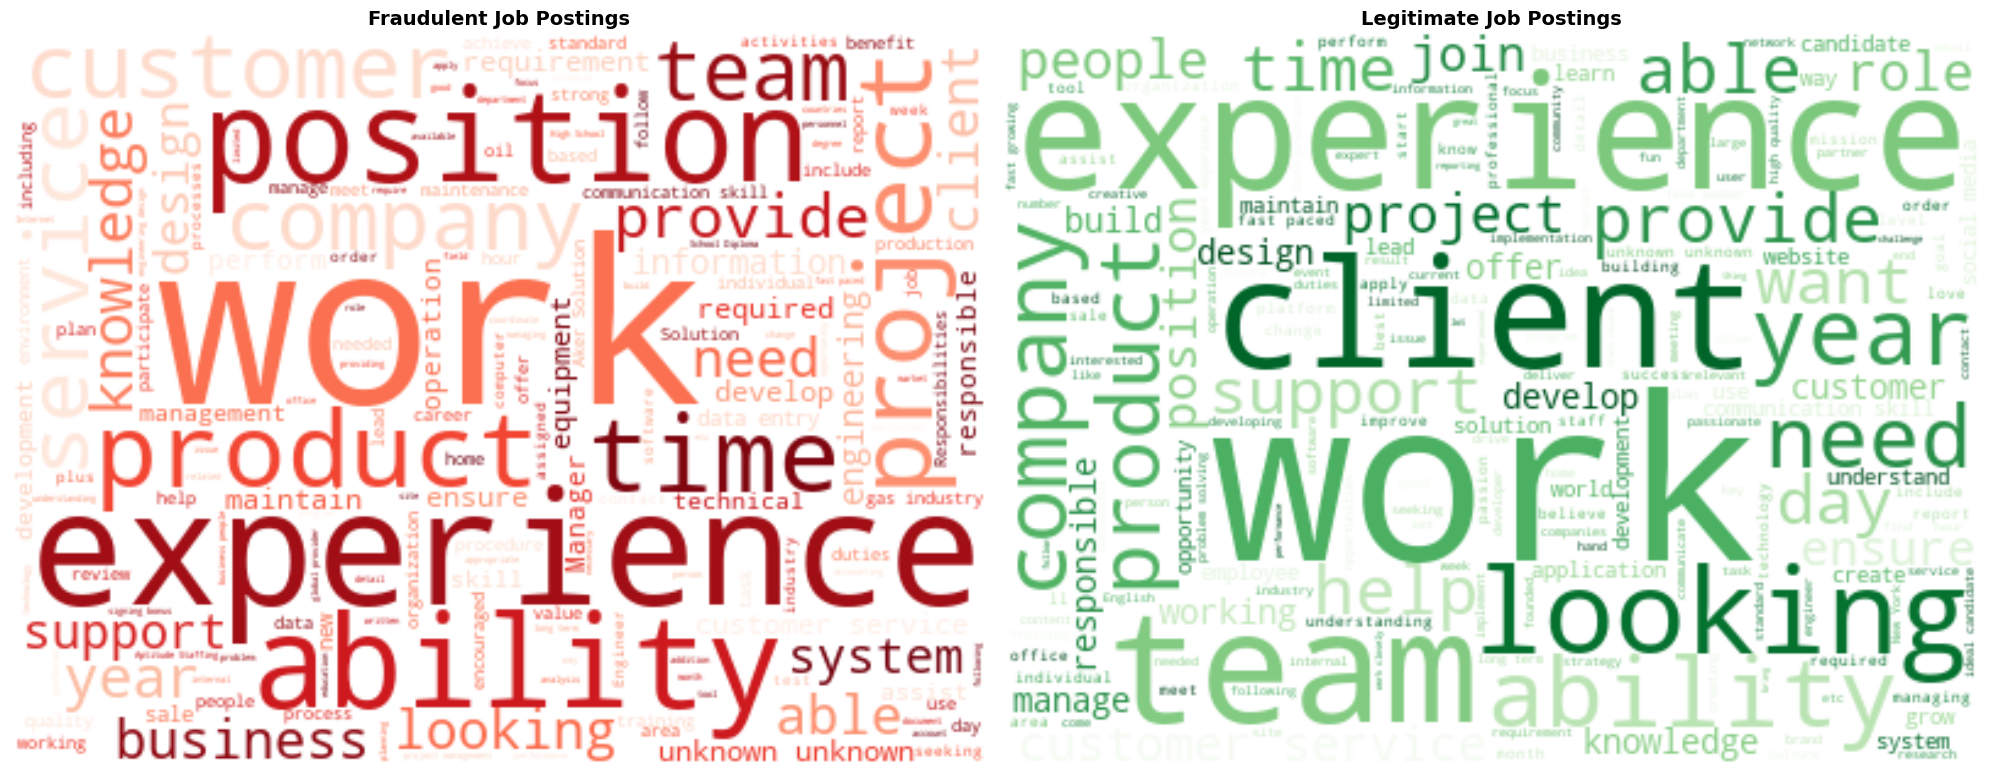

In [20]:
SPODWORDS = spacy.lang.en.stop_words.STOP_WORDS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Fraudulent wordcloud
fraudulent_wc = WordCloud(
    stopwords=STOP_WORDS, width=400, height=300, 
    background_color='white', colormap='Reds'
).generate(' '.join(fraudulent_text))

ax1.imshow(fraudulent_wc, interpolation='bilinear')
ax1.set_title('Fraudulent Job Postings', fontsize=14, fontweight='bold')
ax1.axis('off')

# Legitimate wordcloud  
legitimate_text = job_postings[job_postings['fraudulent'] == 0]['text'].dropna()
legitimate_wc = WordCloud(
    stopwords=STOP_WORDS, width=400, height=300,
    background_color='white', colormap='Greens'
).generate(' '.join(legitimate_text))

ax2.imshow(legitimate_wc, interpolation='bilinear')
ax2.set_title('Legitimate Job Postings', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

### Problem 9: Score the Model

What is the accuracy of your model?

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions